# Setup

In [1]:
%run notebook_setup.py

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import polars as pl
import pandas as pd
import logging
import gc
import random
import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from src.config.dir_config import OUTPUT_PATH_DEMAND_SUMMARY
from src.config.bigquery_config import CREDENTIALS_GBQ, PROJECT_ID_GBQ
from src.utils.read_data import read_data
from src.utils.setup_logging import setup_logging
from src.utils.create_week_date import add_week_start_date
from src.utils.export_as_excel import export_dataframes_as_tables


import logging

setup_logging()

Now you can import modules from the project root: /bi/workspace/Projects/Forecast/forecast


In [2]:
from src.utils.add_dimensions import add_dimensions
from src.utils.create_week_date import add_week_start_date

# Import data

In [3]:
data_genex = pd.read_parquet('../data/processed/genex_data_processed.parquet')
data_genex = add_week_start_date(data_genex)
data_genex = add_dimensions(data_genex)

2025-09-10 15:56:38,919 - INFO - Reading maestros...
2025-09-10 15:56:38,925 - INFO -          Ejecutando consulta en BigQuery, descarga rápida: False...
Downloading: 100%|██████████|
2025-09-10 15:56:40,961 - INFO -          Ejecutando consulta en BigQuery, descarga rápida: True...
Downloading: 100%|██████████|
2025-09-10 15:56:50,517 - INFO - Total time taken 9.54 s.
Finished at 2025-09-10 15:56:50.
2025-09-10 15:56:50,905 - INFO - Merging maestro_sucursal...
2025-09-10 15:56:54,519 - INFO - Merging maestro_producto...


In [4]:
data_transfers = pd.read_parquet('../data/processed/trf_data_processed.parquet')
data_transfers = add_week_start_date(data_transfers)
data_transfers = add_dimensions(data_transfers)

2025-09-10 15:57:23,712 - INFO - Reading maestros...
2025-09-10 15:57:23,713 - INFO -          Ejecutando consulta en BigQuery, descarga rápida: False...
Downloading: 100%|██████████|
2025-09-10 15:57:24,720 - INFO -          Ejecutando consulta en BigQuery, descarga rápida: True...
Downloading: 100%|██████████|
2025-09-10 15:57:36,152 - INFO - Total time taken 11.43 s.
Finished at 2025-09-10 15:57:36.
2025-09-10 15:57:36,555 - INFO - Merging maestro_sucursal...
2025-09-10 15:57:37,709 - INFO - Merging maestro_producto...


# ETL

In [5]:
data_genex_processed = data_genex.copy()

In [6]:
temporada = 'Invierno'
ano = '2025'

data_genex_processed = data_genex_processed.query('nombre_temporada == @temporada and ano_temporada == @ano')

In [7]:
valid_deptos = data_genex_processed[['nombre_depto']].value_counts(normalize=True).reset_index().query('proportion > 0.0')
valid_deptos = valid_deptos[~valid_deptos['nombre_depto'].str.contains('e-com', na=False)]['nombre_depto'].to_list()
len(valid_deptos)

14

In [8]:
valid_sucursales = data_genex_processed[['nombre_sucursal']].value_counts(normalize=True, sort=True, ascending=True).reset_index().round(5).query('proportion > 0.005')['nombre_sucursal'].to_list()
len(valid_sucursales)

103

In [9]:
data_genex_processed = data_genex_processed[data_genex_processed['nombre_depto'].isin(valid_deptos)
                                            & data_genex_processed['nombre_sucursal'].isin(valid_sucursales)]

In [10]:
data_genex_processed['nombre_depto'] = (
    data_genex_processed['nombre_depto']
    .astype('category')                # asegurar que es categorical
    .cat.remove_unused_categories()    # borrar categorías fantasma
)


data_genex_processed['nombre_sucursal'] = (
    data_genex_processed['nombre_sucursal']
    .astype('category')                # asegurar que es categorical
    .cat.remove_unused_categories()    # borrar categorías fantasma
)


In [11]:
conditions = [
    (data_genex_processed['repo_x_dda'] == 0) & (data_genex_processed['repo_x_ume'] == 0),
    data_genex_processed['repo_x_dda'] > data_genex_processed['repo_x_ume'],
    data_genex_processed['repo_x_dda'] < data_genex_processed['repo_x_ume'],
    data_genex_processed['repo_x_dda'] == data_genex_processed['repo_x_ume']
]

choices = ['No pide','Demanda', 'UME', 'Iguales']

data_genex_processed['tipo_repo'] = np.select(conditions, choices, default="No aplica")
data_genex_processed['tipo_repo'] = data_genex_processed['tipo_repo'].astype('category')

In [12]:
map_clasif = {
    "BOTTOM INTELIG": "BOTTOM INTELIGENTE",
    "TOP INTELIGENT": "TOP INTELIGENTE",
    "MAL PERFORMANC": "MAL PERFORMANCE",
}

data_genex_processed['clasif'] = data_genex_processed['clasif'].str.strip().str.upper()
data_genex_processed['clasif'] = data_genex_processed['clasif'].replace(map_clasif)

# EDA

# a) Por tipo repo

In [13]:
data_by_tipo = data_genex_processed.groupby(['tipo_repo'], observed=True, as_index=False).agg(
    can_original =('can_original', 'sum'),
    can_final =('can_final', 'sum'),
    repo_x_dda =('repo_x_dda', 'sum'),
    repo_x_ume =('repo_x_ume', 'sum'),
    vta_promedio = ('vta_promedio', 'mean'),
    factor = ('factor', 'mean'),
    semana_vta = ('semana_vta', 'mean'),
    ume = ('ume', 'mean'),
).sort_values(by='can_final', ascending=False)

data_by_tipo['can_final_pct'] = (data_by_tipo['can_final'] / data_by_tipo['can_final'].sum()).round(4)

data_by_tipo['satisfaction_rate'] = (data_by_tipo['can_final'] / data_by_tipo['can_original']).round(4)

data_by_tipo = data_by_tipo.query('can_final_pct > 0.01')

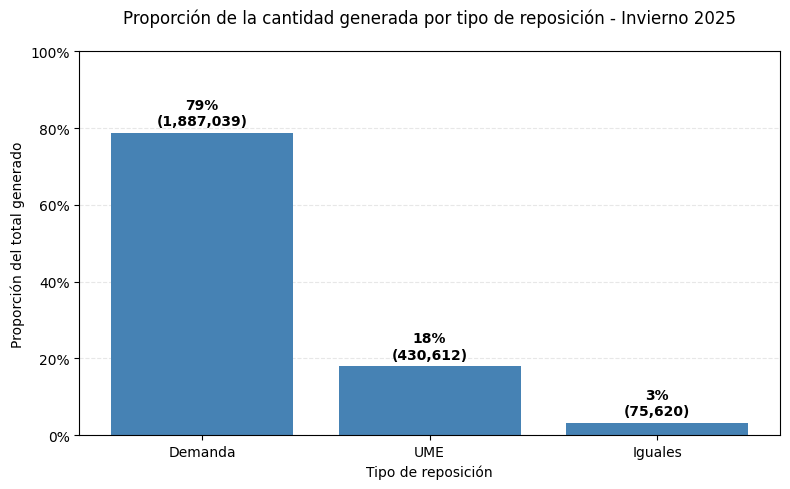

In [14]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    data=data_by_tipo,
    x = 'tipo_repo',
    height='can_final_pct',
    align='center',
    color='steelblue',
    zorder=2
)

plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.2))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.ylim(0, 1)


plt.ylabel("Proporción del total generado")
plt.xlabel("Tipo de reposición")

plt.title("Proporción de la cantidad generada por tipo de reposición - Invierno 2025", pad=20)

for i, v in enumerate(data_by_tipo['can_final_pct']):
    plt.text(i, v + 0.02, f'{v:.0%}\n({data_by_tipo["can_final"].iloc[i]:,})', ha='center', fontweight='bold', zorder = 3)

plt.tight_layout()
plt.grid(axis="y", linestyle='--', alpha=0.3)
plt.show()

# EDA Transfer

In [15]:
data_transfers_processed = data_transfers.copy()
data_transfers_processed = data_transfers_processed[~data_transfers_processed['nombre_depto'].str.contains('e-com', na=False)]
data_transfers_processed = data_transfers_processed[data_transfers_processed['nombre_depto'] != 'Miscelaneos']
data_transfers_processed = data_transfers_processed[data_transfers_processed['nombre_sucursal'].isin(valid_sucursales)]
data_transfers_processed = data_transfers_processed.query('(nombre_temporada == "Verano" and ano_temporada == "2024") or (nombre_temporada == "Invierno" and ano_temporada == "2025")')

In [16]:
print(data_transfers_processed['nombre_depto'].nunique())
print(data_transfers_processed['nombre_sucursal'].nunique())

21
103


## a) Distribución transferencias

In [17]:
data_transfers_processed_gb = data_transfers_processed.groupby(['nombre_temporada','ano_temporada','nombre_razon_group'], observed=True, as_index=False).agg(
    cantidad_apr = ('cantidad_apr', 'sum'),
    cantidad_can = ('cantidad_can', 'sum'),
    cantidad_des = ('cantidad_des', 'sum'),
)

data_transfers_processed_gb['cantidad_des_pct'] = (data_transfers_processed_gb['cantidad_des'] / data_transfers_processed_gb.groupby(['nombre_temporada','ano_temporada'], observed=True)['cantidad_des'].transform('sum')).round(4)

data_transfers_processed_gb = data_transfers_processed_gb.sort_values(by=['ano_temporada','nombre_temporada','cantidad_des_pct'], ascending=[False, True, False])

data_transfers_processed_gb['season'] = (
    data_transfers_processed_gb['nombre_temporada'].astype(str)
    + ' '
    + data_transfers_processed_gb['ano_temporada'].astype(str)
)

data_transfers_processed_gb.sort_values(['nombre_razon_group','season'],
                                        ascending = [True, False])

,nombre_temporada,ano_temporada,nombre_razon_group,cantidad_apr,cantidad_can,cantidad_des,cantidad_des_pct,season
4,Verano,2024,PREDISTRIBUIDA,6820395,5001,6804530,0.5615,Verano 2024
0,Invierno,2025,PREDISTRIBUIDA,4336427,92,4327210,0.4943,Invierno 2025
5,Verano,2024,REPOSICION AUTOMATIC,3304619,31128,3270214,0.2698,Verano 2024
1,Invierno,2025,REPOSICION AUTOMATIC,3051926,25250,3016529,0.3446,Invierno 2025
6,Verano,2024,CARGA MANUAL,1615515,16218,1598997,0.1319,Verano 2024
2,Invierno,2025,CARGA MANUAL,1278884,7696,1228199,0.1403,Invierno 2025
7,Verano,2024,OTRAS,460603,15410,445004,0.0367,Verano 2024
3,Invierno,2025,OTRAS,193804,658,181955,0.0208,Invierno 2025


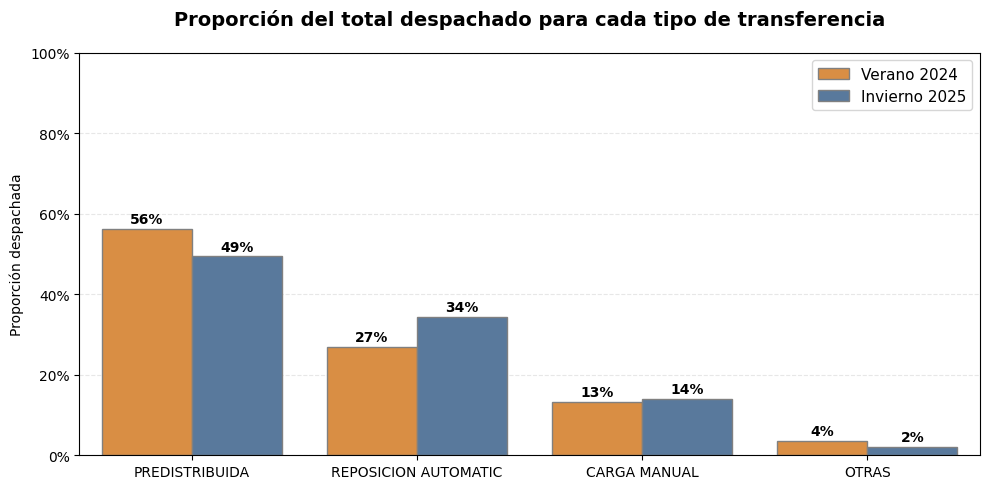

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.figure(figsize=(10, 5))

# Colores
palette = {
    "Verano 2024": "#F28E2B",   # Naranjo cálido
    "Invierno 2025": "#4E79A7"  # Azul cálido
}

ax = sns.barplot(
    data=data_transfers_processed_gb,
    x="nombre_razon_group",
    y="cantidad_des_pct",
    hue="season",
    hue_order=["Verano 2024", "Invierno 2025"],
    palette=palette,
    edgecolor="gray",
    zorder=2
)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.ylim(0, 1)

plt.title(
    "Proporción del total despachado para cada tipo de transferencia",
    pad=20,
    fontdict={'weight': 'bold', 'size': 14}
)
plt.ylabel("Proporción despachada")
plt.xlabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{p.get_height():.0%}" for p in container],
        padding=2,
        fontsize=10,
        fontweight="bold"
    )

ax.legend(
    title="",
    fontsize=11,
    loc="upper right"
)

plt.xticks(rotation=0, ha="center")
plt.tight_layout()

plt.grid(axis="y", linestyle='--', alpha=0.3, zorder=1)

plt.show()

## b) Frecuencia repo automatica

In [19]:
data_repo_auto = data_transfers_processed.query('nombre_razon_group == "REPOSICION AUTOMATIC"').copy()

In [20]:
data_repo_auto_gb = data_repo_auto.groupby(['nombre_temporada','ano_temporada', 'cod_sucursal','cod_producto','cod_talla'], observed=True, as_index=False).agg(
    n_transfers = ('numero_trf', 'count'),
    q_transfer = ('cantidad_des', 'sum')
    )

data_repo_auto_gb['n_transfers_group'] = pd.cut(
    data_repo_auto_gb['n_transfers'],
    bins=[0, 1, 2, 3, 4, np.inf],   # hasta infinito
    labels=['1', '2', '3', '4', '5+'],  # la última es 5+
    right=True
)

data_repo_auto_gb['season'] = (
    data_repo_auto_gb['nombre_temporada'].astype(str)
    + ' '
    + data_repo_auto_gb['ano_temporada'].astype(str)
)

freq_pct = data_repo_auto_gb.groupby(['season','n_transfers_group'], observed=True, as_index=False).size()
freq_pct['freq_pct'] = (freq_pct['size'] / freq_pct.groupby('season')['size'].transform('sum')).round(4)

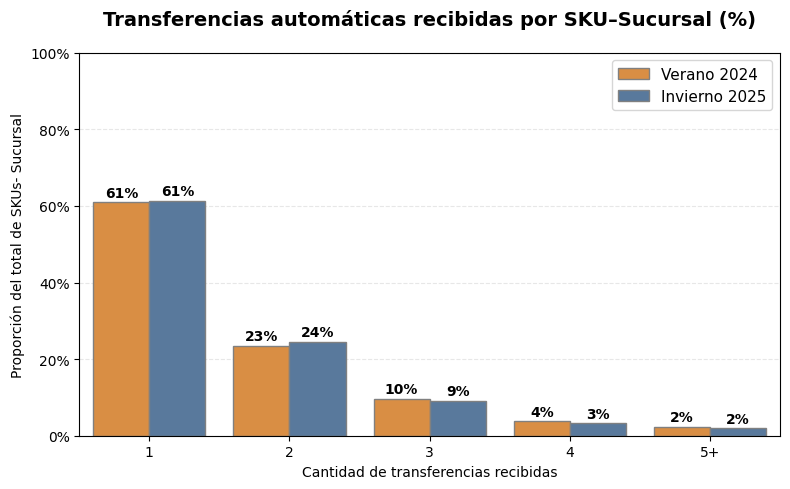

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=freq_pct,
    x='n_transfers_group',
    y='freq_pct',   # respetamos tu columna
    hue='season',
    hue_order=['Verano 2024', 'Invierno 2025'],
    palette=palette,
    edgecolor='gray',
    zorder=2,
    ax=ax
)

# Eje Y en % (0 a 100)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.ylim(0, 1)

# Títulos y etiquetas
plt.title(
    "Transferencias automáticas recibidas por SKU–Sucursal (%)",
    pad=20,
    fontdict={'weight': 'bold', 'size': 14}
)
plt.ylabel("Proporción del total de SKUs- Sucursal")
plt.xlabel("Cantidad de transferencias recibidas")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{p.get_height():.0%}" for p in container],  # convierte 0.25 → 25%
        padding=2,
        fontsize=10,
        fontweight="bold"
    )

# Leyenda
ax.legend(
    title="",
    fontsize=11,
    loc="upper right"
)

plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.grid(axis="y", linestyle='--', alpha=0.3, zorder=1)

plt.show()
